In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## description of dataset
**Context**<br>
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

**Content**<br>
The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

## column description
- Pregnancies:- Number of times the patient has been pregnant
- Glucose :- Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- BloodPressure:-Diastolic blood pressure (mm Hg)
- SkinThickness :-Triceps skin fold thickness (mm)
- Insulin:- 2-Hour serum insulin (mu U/ml)
- BMI:- Body mass index (weight in kg/(height in m)^2)
- DiabetesPedigreeFunction:- Likelihood of diabetes based on family history
- Age :- age 
- Outcome:- 0 = No Diabetes, 1 = Diabetes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


these columns has 0 value it not possible logically
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI<br>
replace it with nan

In [10]:
diabetes=df.copy(deep=True)

In [11]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [14]:
diabetes[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]=diabetes[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

In [15]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [16]:
diabetes.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [17]:
diabetes['Glucose'].describe()

count    763.000000
mean     121.686763
std       30.535641
min       44.000000
25%       99.000000
50%      117.000000
75%      141.000000
max      199.000000
Name: Glucose, dtype: float64

<Axes: >

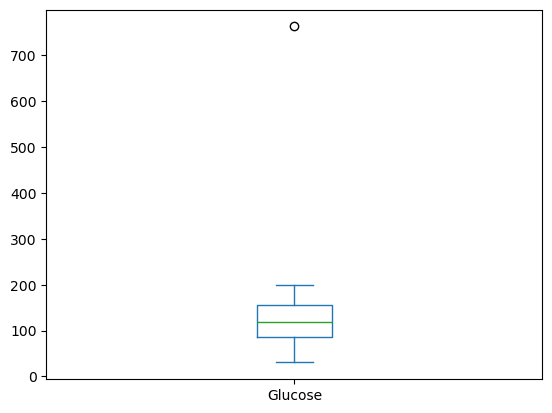

In [18]:
diabetes['Glucose'].describe().plot(kind='box')

In [21]:
diabetes['Glucose'].sort_values(ascending=False).head(10)

661    199.0
561    198.0
8      197.0
408    197.0
579    197.0
228    197.0
22     196.0
359    196.0
206    196.0
498    195.0
Name: Glucose, dtype: float64

you can replace nan with mean

In [22]:
diabetes['Glucose'].fillna(diabetes['Glucose'].mean(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_34516\2667914461.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes['Glucose'].fillna(diabetes['Glucose'].mean(),inplace=True)


In [24]:
diabetes['Glucose'].isnull().sum()

np.int64(0)

**BloodPressure**


In [25]:
diabetes['BloodPressure'].describe()

count    733.000000
mean      72.405184
std       12.382158
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [26]:
diabetes['BloodPressure'].fillna(diabetes['BloodPressure'].mean(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_34516\275548675.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes['BloodPressure'].fillna(diabetes['BloodPressure'].mean(),inplace=True)


In [28]:
diabetes['BloodPressure'].isnull().sum()

np.int64(0)

In [30]:
diabetes['SkinThickness'].isnull().sum()

np.int64(227)

In [31]:
diabetes['SkinThickness'].describe()

count    541.000000
mean      29.153420
std       10.476982
min        7.000000
25%       22.000000
50%       29.000000
75%       36.000000
max       99.000000
Name: SkinThickness, dtype: float64

<Axes: ylabel='SkinThickness'>

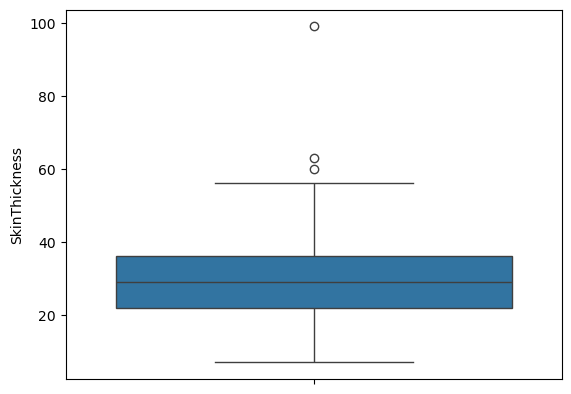

In [33]:
sns.boxplot(data=diabetes,y='SkinThickness')

In [35]:
diabetes['SkinThickness'].sort_values(ascending=False).head(10)

579    99.0
445    63.0
57     60.0
120    56.0
211    54.0
86     54.0
275    52.0
532    52.0
99     51.0
591    50.0
Name: SkinThickness, dtype: float64

it has outliers then fill with median

In [36]:
diabetes['SkinThickness'].fillna(diabetes['SkinThickness'].median(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_34516\2584848369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes['SkinThickness'].fillna(diabetes['SkinThickness'].median(),inplace=True)


In [37]:
diabetes['SkinThickness'].isnull().sum()

np.int64(0)

In [39]:
diabetes['Insulin'].isnull().sum()

np.int64(374)

In [40]:
diabetes['Insulin'].describe()

count    394.000000
mean     155.548223
std      118.775855
min       14.000000
25%       76.250000
50%      125.000000
75%      190.000000
max      846.000000
Name: Insulin, dtype: float64

It has outliers then fill with median

In [41]:
diabetes['Insulin'].fillna(diabetes['Insulin'].median(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_34516\1203594194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes['Insulin'].fillna(diabetes['Insulin'].median(),inplace=True)


In [42]:
diabetes['Insulin'].isnull().sum()

np.int64(0)

In [44]:
diabetes['BMI'].isnull().sum()

np.int64(11)

In [45]:
diabetes['BMI'].describe()

count    757.000000
mean      32.457464
std        6.924988
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [46]:
diabetes['BMI'].sort_values(ascending=False)

177    67.1
445    59.4
673    57.3
125    55.0
120    53.2
       ... 
426     NaN
494     NaN
522     NaN
684     NaN
706     NaN
Name: BMI, Length: 768, dtype: float64

In [47]:
diabetes['BMI'].fillna(diabetes['BMI'].median(),inplace=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_34516\271241927.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes['BMI'].fillna(diabetes['BMI'].median(),inplace=True)


In [48]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


<Axes: xlabel='Outcome'>

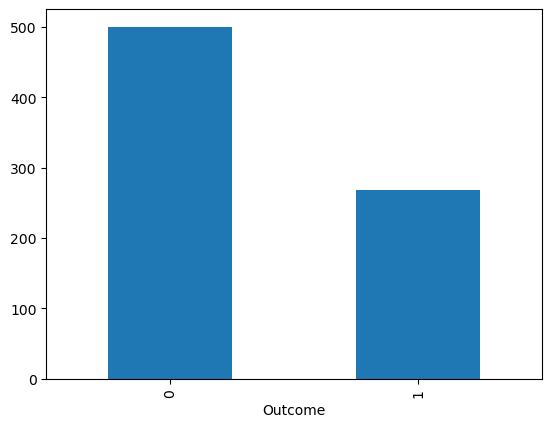

In [51]:
diabetes['Outcome'].value_counts().plot(kind='bar')

In [61]:
diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

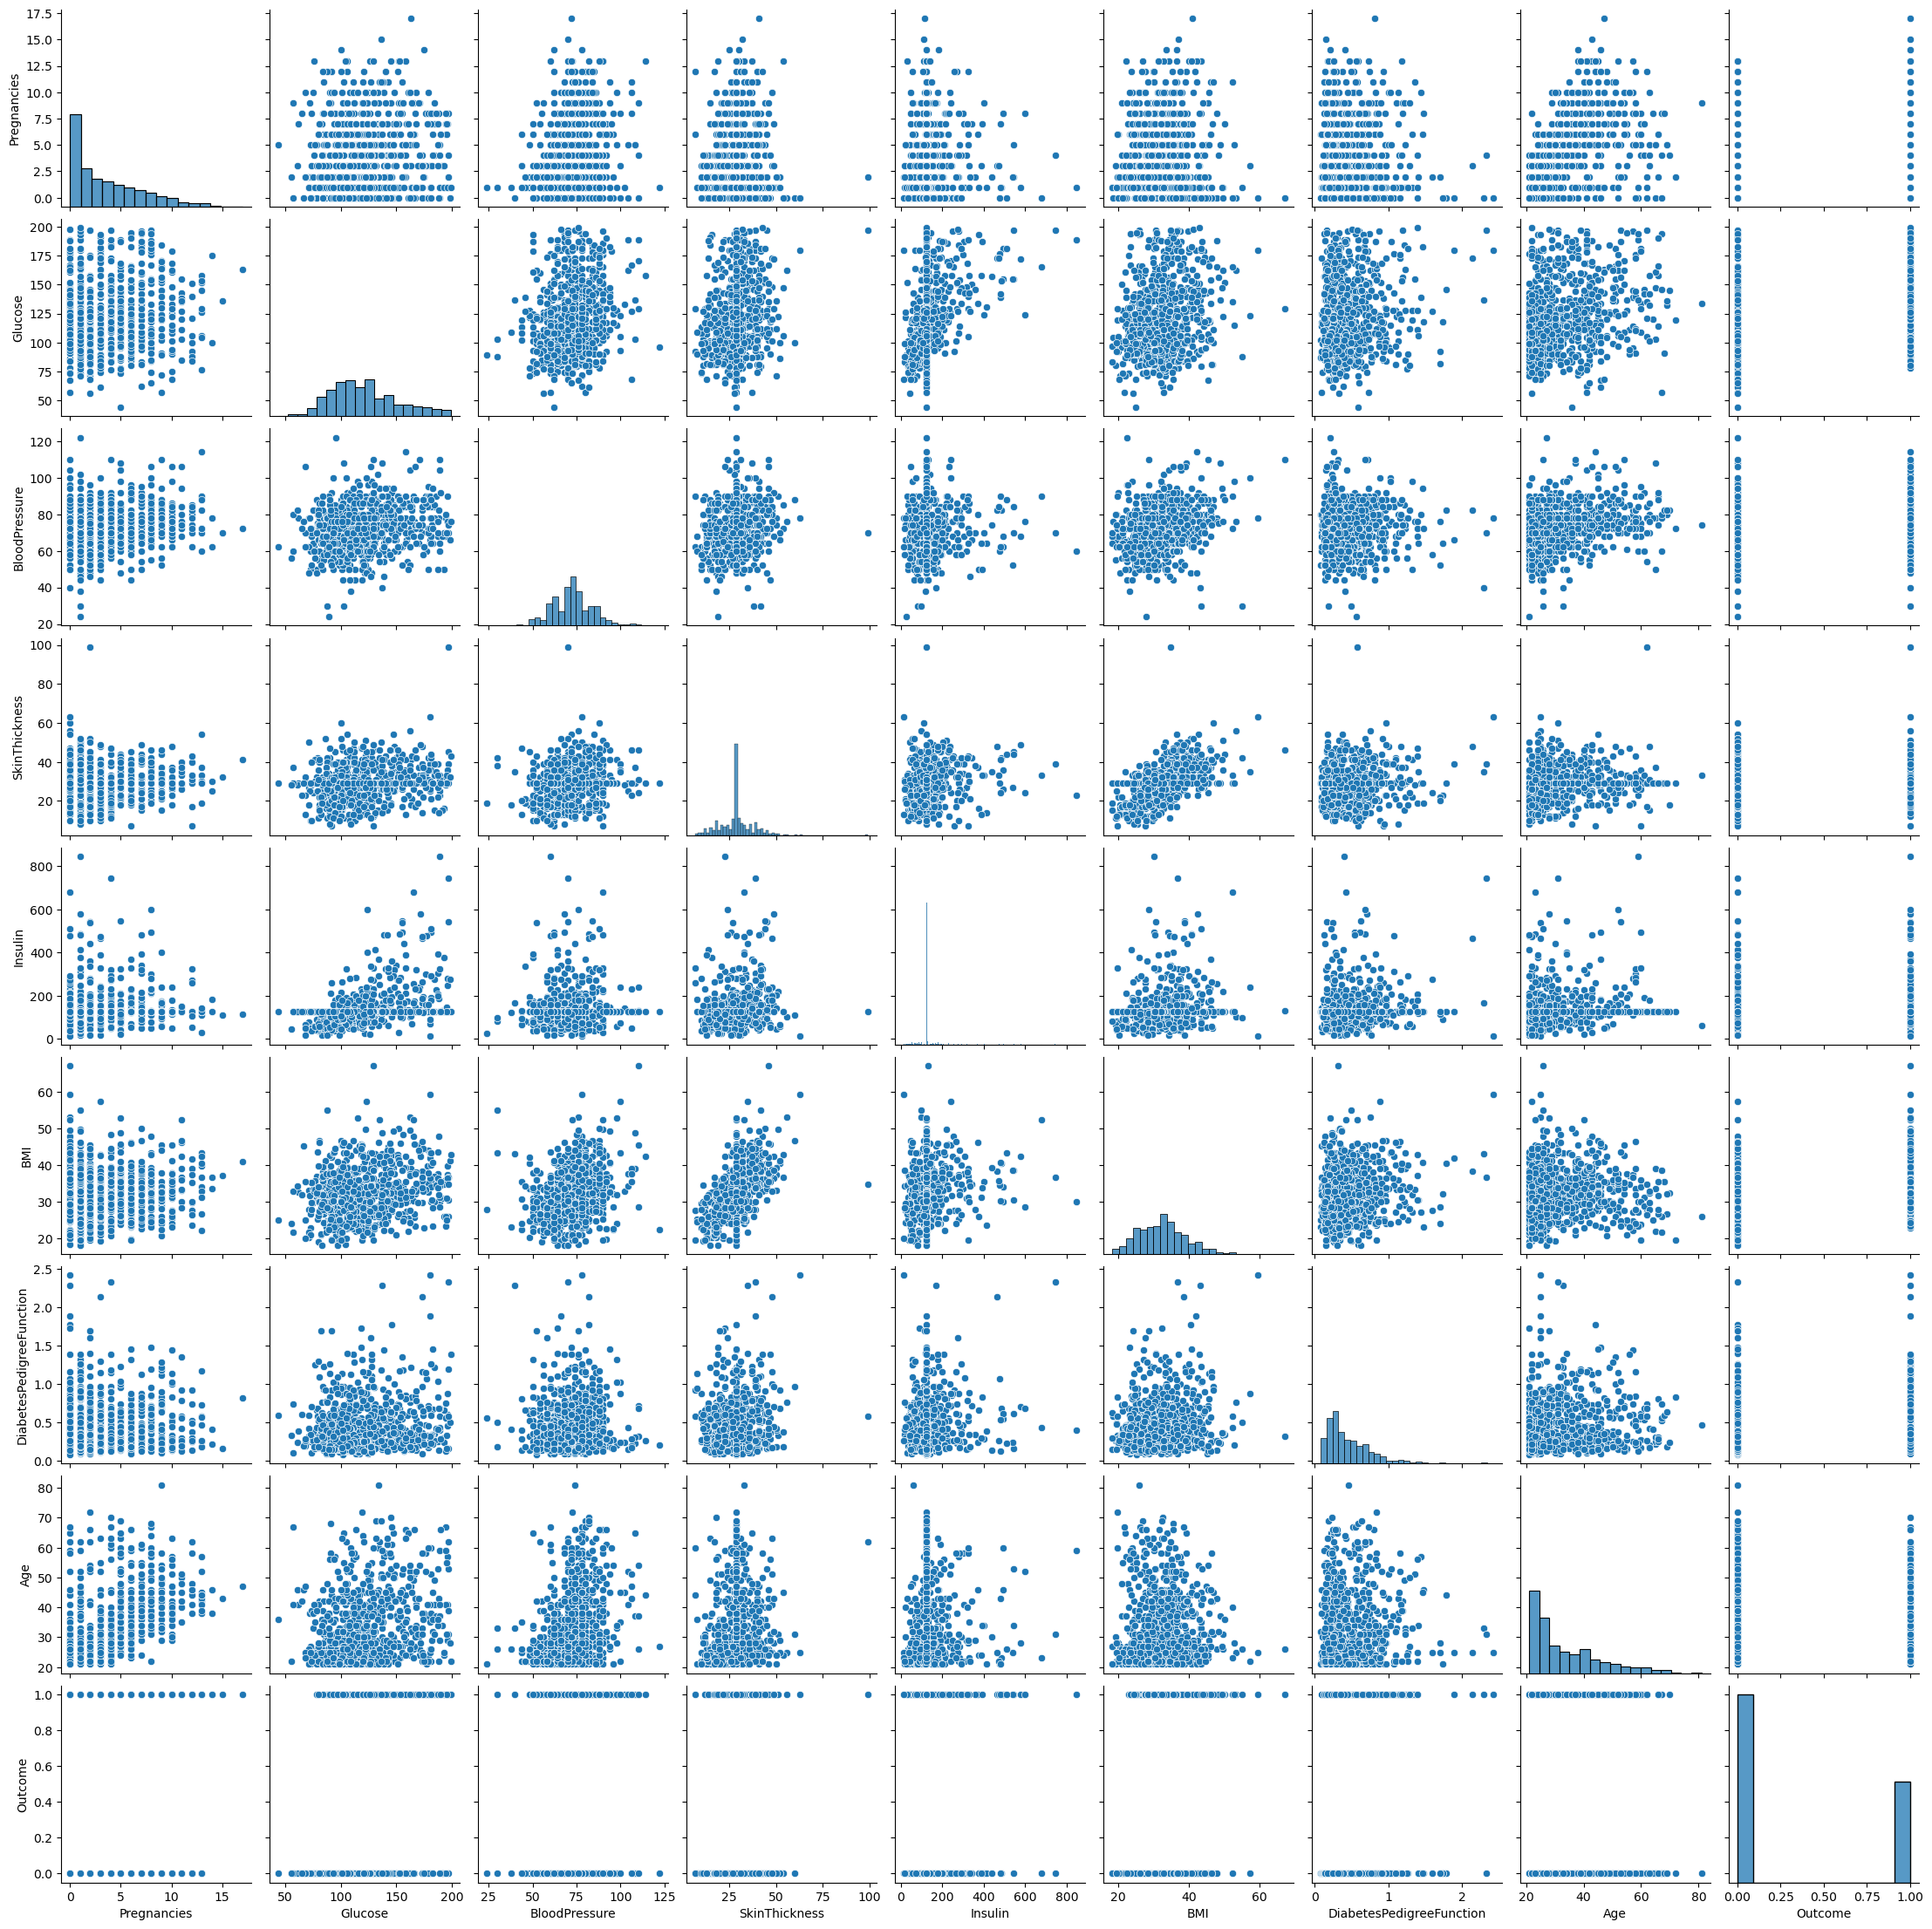

In [62]:

sns.pairplot(data=diabetes)

<Axes: >

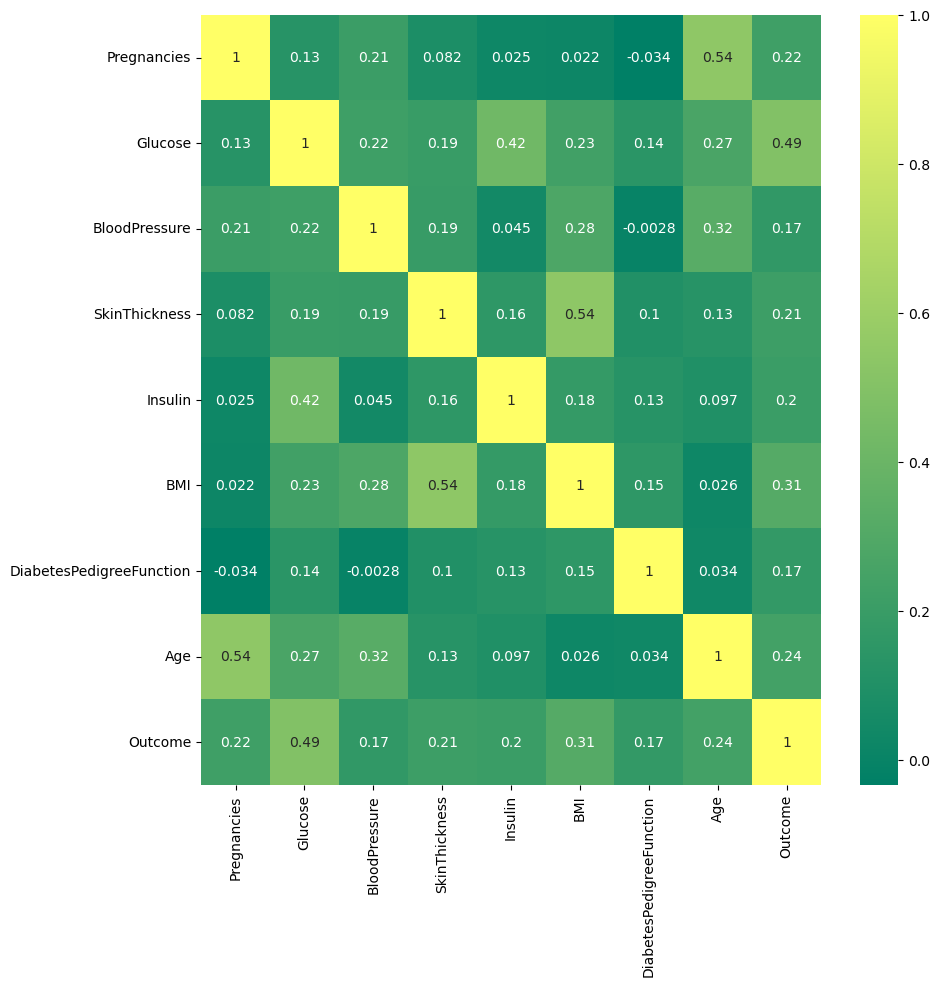

In [108]:
plt.figure(figsize=(10,10))
sns.heatmap(diabetes.corr(),annot=True,cmap='summer')

In [67]:
h=pd.crosstab(diabetes['Glucose'],diabetes['Outcome'],normalize='index')*100
h

Outcome,0,1
Glucose,,
44.0,100.0,0.0
56.0,100.0,0.0
57.0,100.0,0.0
61.0,100.0,0.0
62.0,100.0,0.0
...,...,...
195.0,0.0,100.0
196.0,0.0,100.0
197.0,25.0,75.0


<Axes: xlabel='Outcome', ylabel='Glucose'>

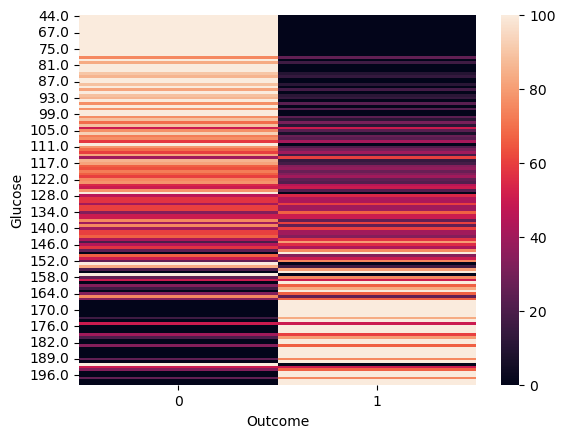

In [68]:
sns.heatmap(data=h)

In [69]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [80]:
h=pd.crosstab(diabetes['Pregnancies'],diabetes['Outcome'],normalize='index')*100
h

Outcome,0,1
Pregnancies,,
0,65.765766,34.234234
1,78.518519,21.481481
2,81.553398,18.446602
3,64.000000,36.000000
4,66.176471,33.823529
5,63.157895,36.842105
6,68.000000,32.000000
7,44.444444,55.555556
8,42.105263,57.894737


<Axes: xlabel='Outcome', ylabel='Pregnancies'>

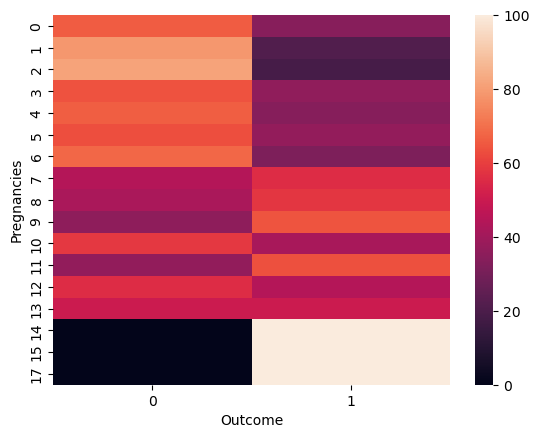

In [81]:
sns.heatmap(data=h)

In [84]:
h=pd.crosstab(diabetes['SkinThickness'],diabetes['Outcome'],normalize='index')*100
h

Outcome,0,1
SkinThickness,,
7.0,50.000000,50.000000
8.0,100.000000,0.000000
10.0,100.000000,0.000000
11.0,100.000000,0.000000
12.0,85.714286,14.285714
13.0,90.909091,9.090909
14.0,66.666667,33.333333
15.0,92.857143,7.142857
16.0,100.000000,0.000000


Text(0.5, 1.0, 'SkinThickness')

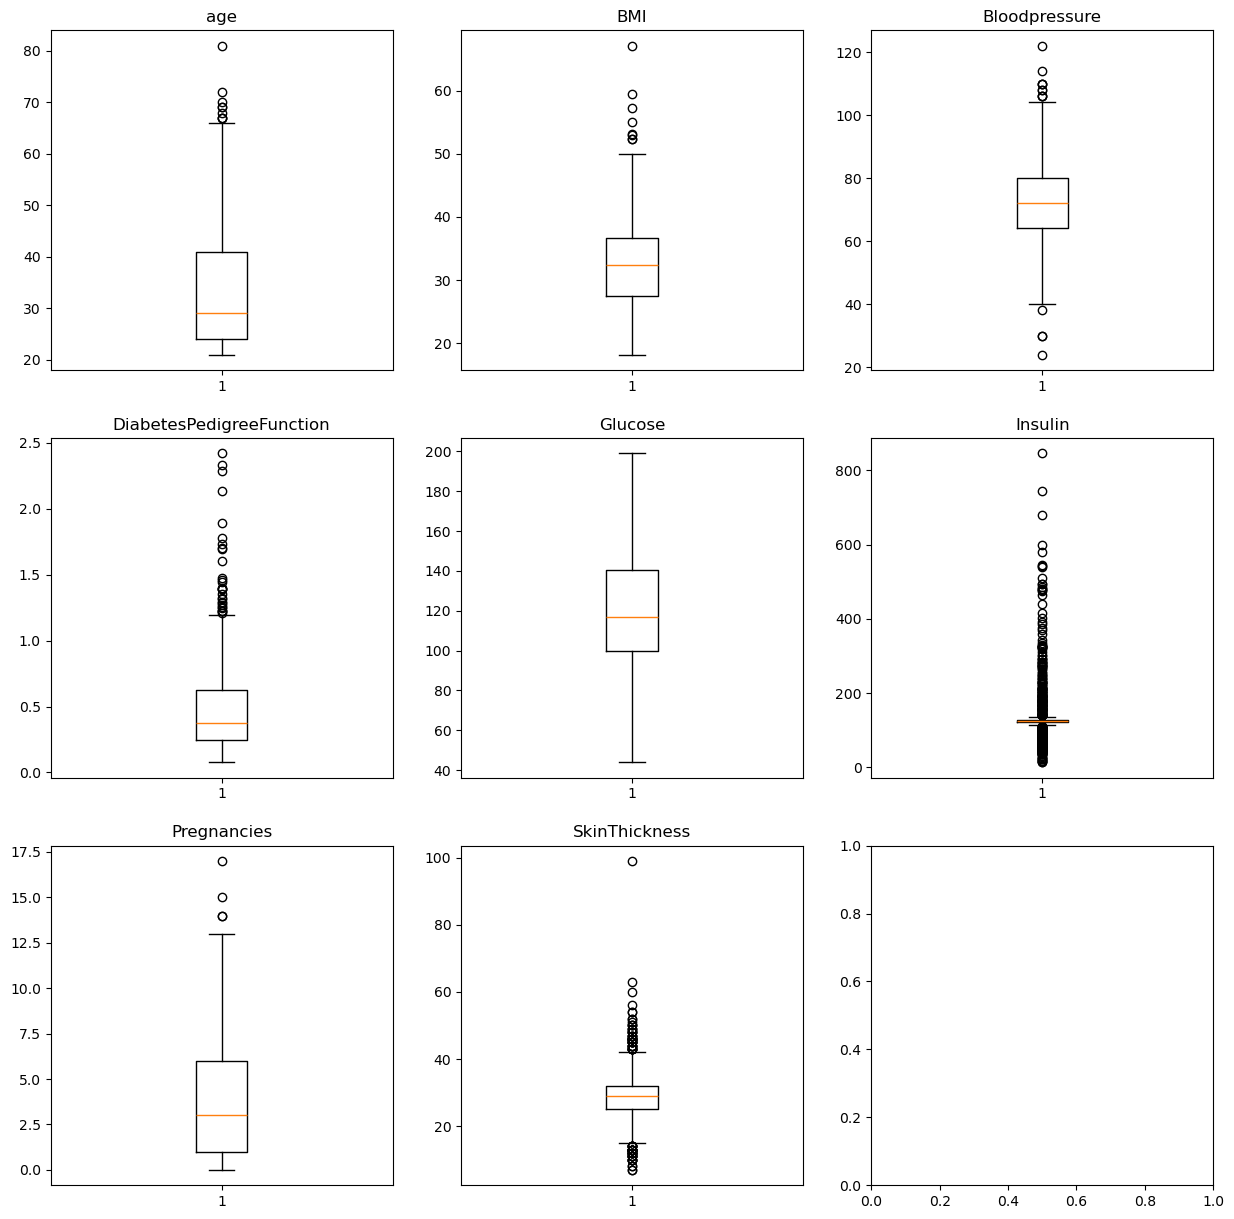

In [96]:
fig, ax=plt.subplots(nrows=3,ncols=3,figsize=(15,15))
ax[0][0].boxplot(diabetes['Age'])
ax[0][0].set_title('age')
ax[0][1].boxplot(diabetes['BMI'])
ax[0][1].set_title('BMI')
ax[0][2].boxplot(diabetes['BloodPressure'])
ax[0][2].set_title('Bloodpressure')
ax[1][0].boxplot(diabetes['DiabetesPedigreeFunction'])
ax[1][0].set_title('DiabetesPedigreeFunction')
ax[1][1].boxplot(diabetes['Glucose'])
ax[1][1].set_title('Glucose')
ax[1][2].boxplot(diabetes['Insulin'])
ax[1][2].set_title('Insulin')
ax[2][0].boxplot(diabetes['Pregnancies'])
ax[2][0].set_title('Pregnancies')
ax[2][1].boxplot(diabetes['SkinThickness'])
ax[2][1].set_title('SkinThickness')

<Axes: ylabel='Insulin'>

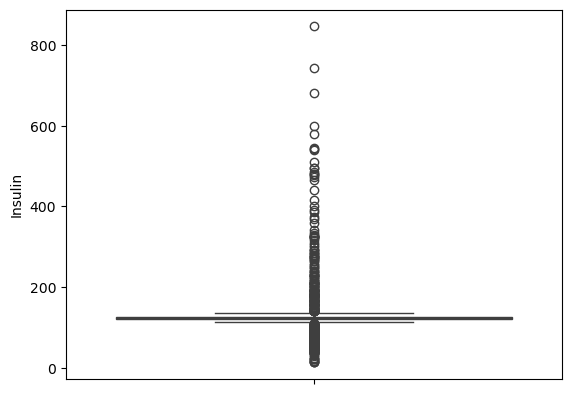

In [102]:
sns.boxplot(data=diabetes,y='Insulin')

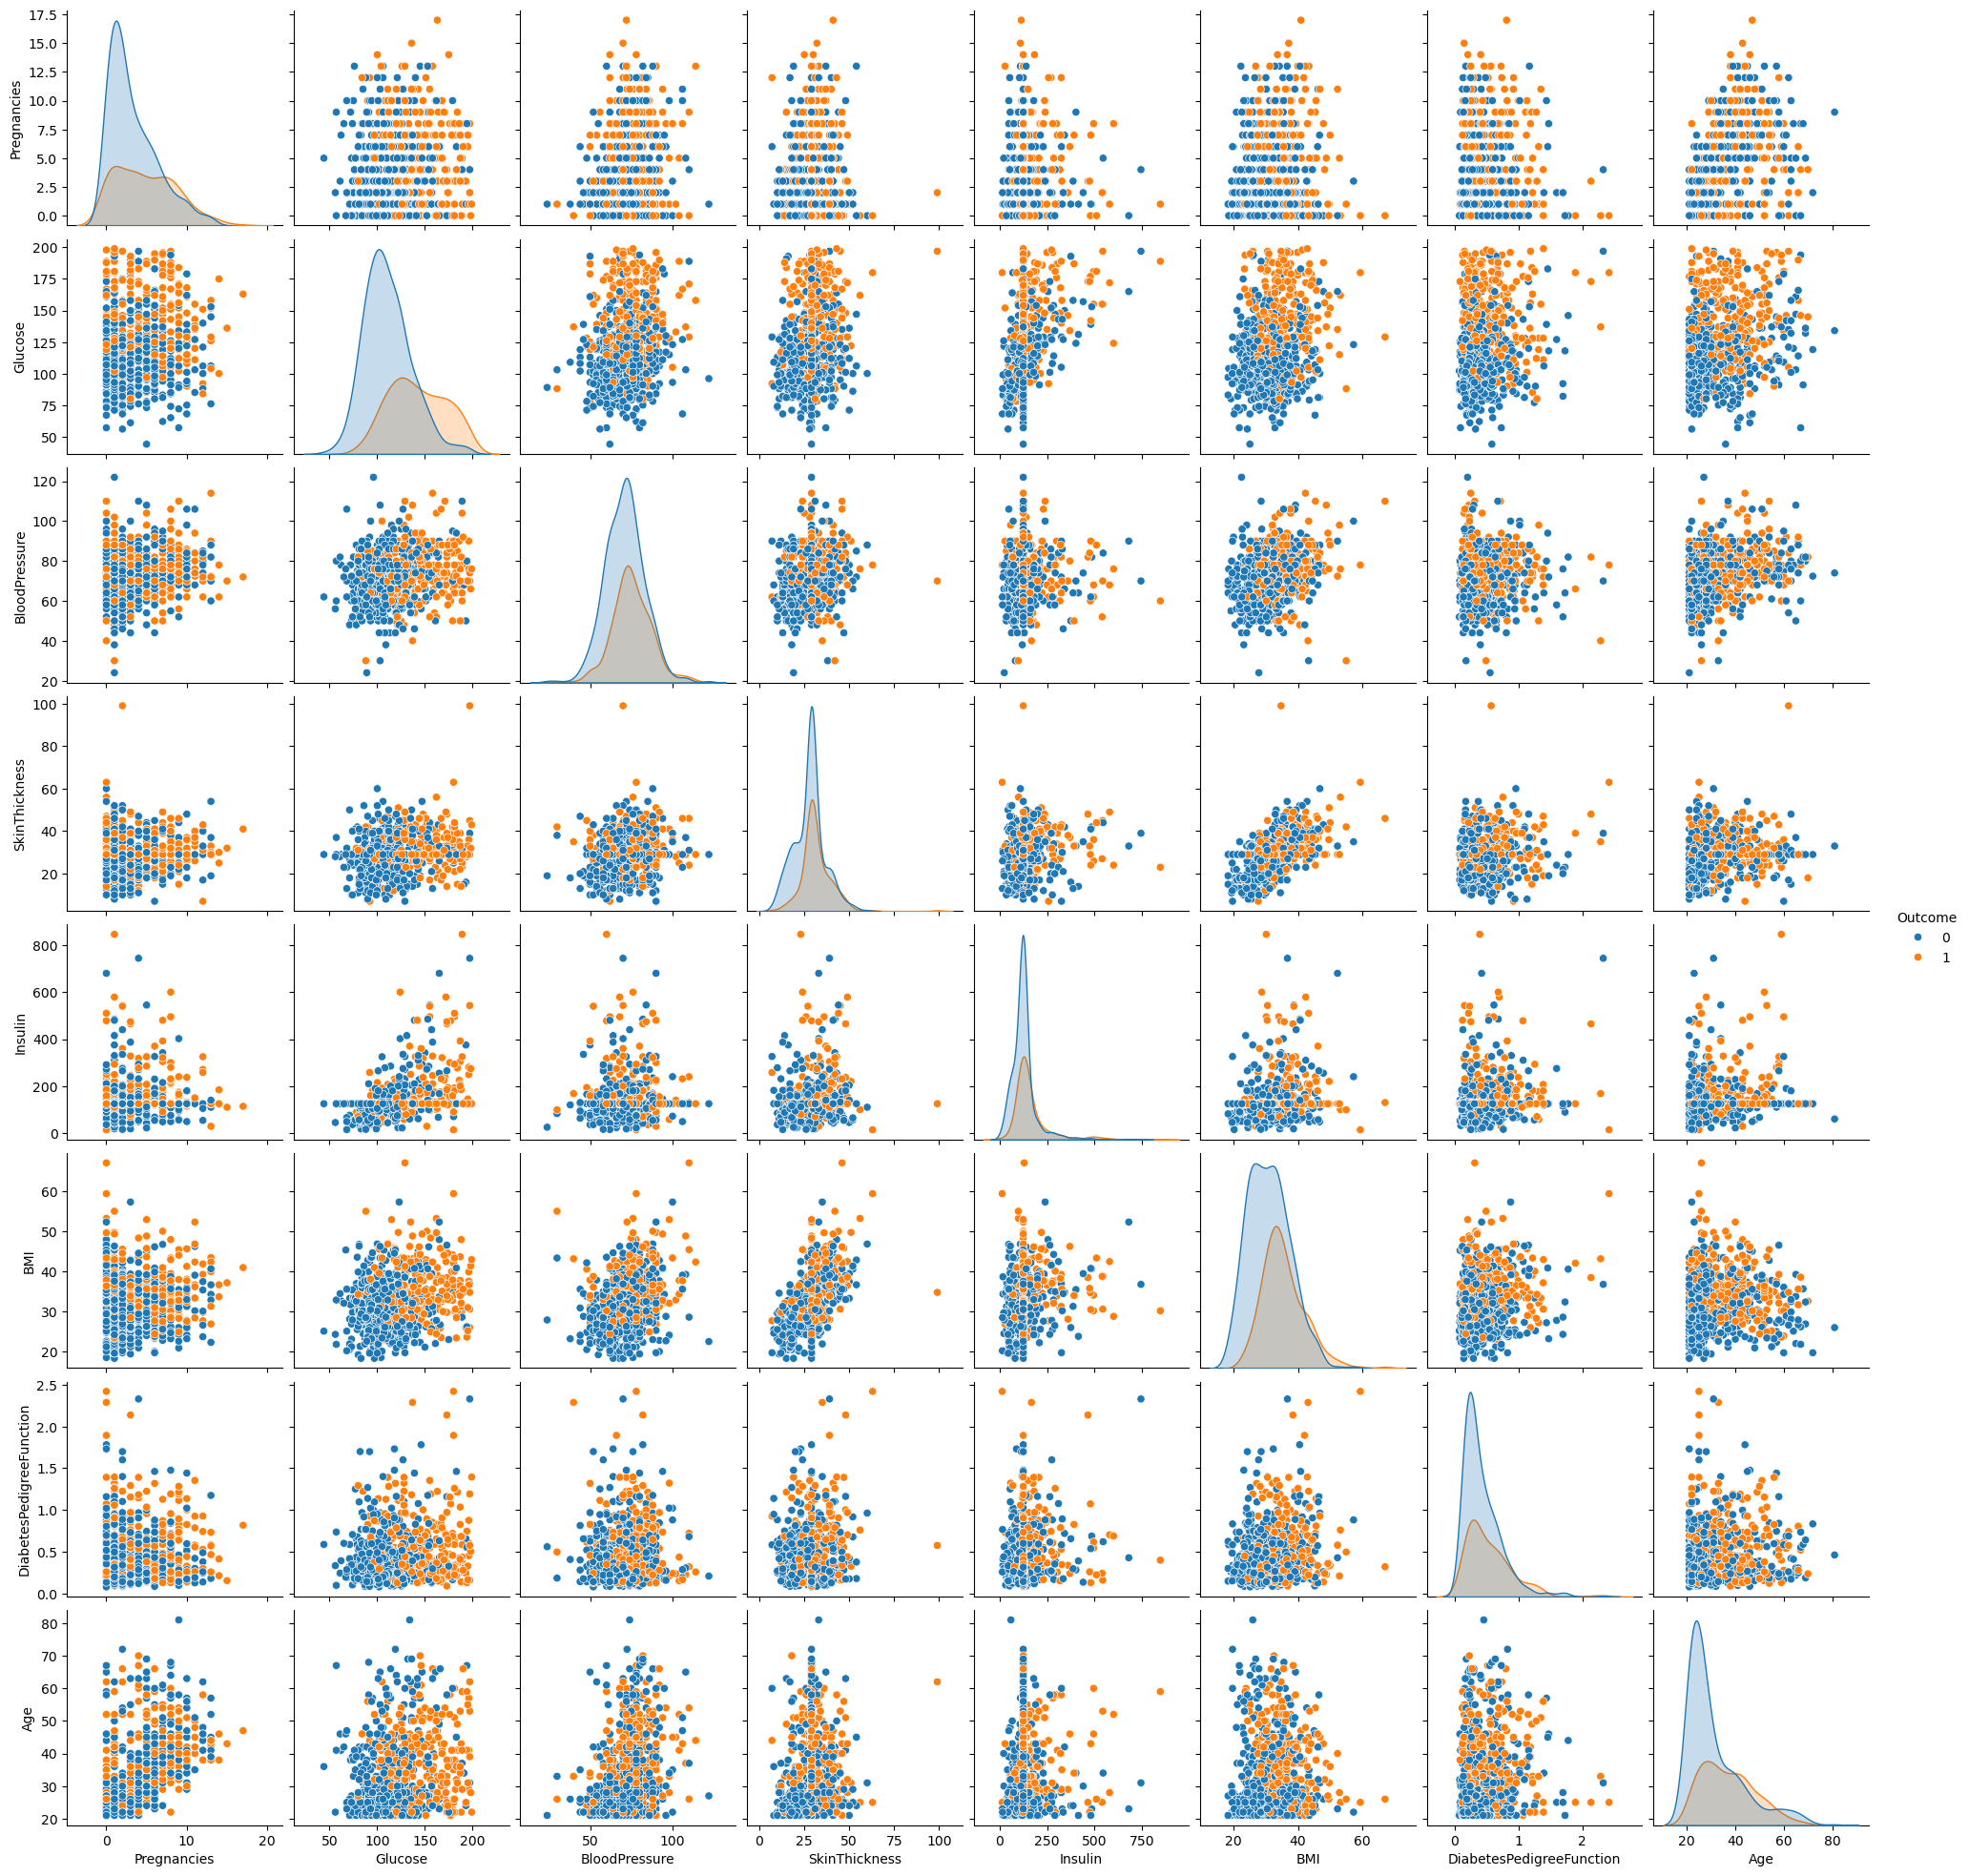

In [110]:
sns.pairplot(diabetes,hue='Outcome')

<Axes: xlabel='Age', ylabel='Count'>

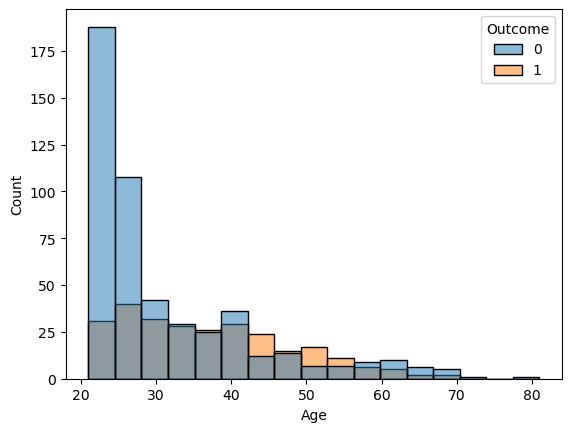

In [117]:
sns.histplot(diabetes,x='Age',hue="Outcome")